In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [5]:

# Load the model architecture
class HeatCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(64 * 54 * 54, 32)
        self.fc2 = nn.Linear(32, 16)
        self.out = nn.Linear(16, 9)

    def forward(self, x):
        out = self.pool(F.relu(self.conv1(x)))
        out = self.pool(F.relu(self.conv2(out)))
        out = out.flatten(1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.out(out)
        return out

# Load the saved model
model = HeatCNN()
model.load_state_dict(torch.load('heatmap_model_state.pth'))
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [6]:
# Load test data (assuming you have the test loader from training)
# If not, recreate it from your pickle files
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from sklearn.model_selection import train_test_split

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdiislam/pressure-sensor-heatmaprgb")

with open(f'{path}/X_9_RGB.pickle', 'rb') as f:
    X = pickle.load(f)
with open(f'{path}/y_9_RGB.pickle', 'rb') as f:
    y = pickle.load(f)

# Prepare transforms
transforms = T.Compose([
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Create dataset class
class HeatmapDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Prepare test data
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, shuffle=True)
X_test = X_test.permute(0, 3, 1, 2)

test_data = HeatmapDataset(X_test, y_test, transform=transforms)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Test set size: {len(test_data)}")


Test set size: 361


In [7]:
# Generate predictions on test set
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        probs = F.softmax(output, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        _, predictions = torch.max(output, 1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(f"Predictions shape: {all_preds.shape}")
print(f"Probabilities shape: {all_probs.shape}")


Predictions shape: (361,)
Probabilities shape: (361, 9)


In [8]:
# Define class names
class_names = [
    'Normal foot',
    'Left foot forward leaned',
    'Right foot forward leaned',
    'Left foot backward leaned',
    'Right foot backward leaned',
    'Left sided lean',
    'Right sided lean',
    'Left foot twisted',
    'Right foot twisted'
]

# Calculate overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("=" * 50)
print("OVERALL METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)


OVERALL METRICS
Accuracy:  0.9945
Precision: 0.9946
Recall:    0.9945
F1-Score:  0.9945


In [9]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))




DETAILED CLASSIFICATION REPORT
                            precision    recall  f1-score   support

               Normal foot     1.0000    1.0000    1.0000        37
  Left foot forward leaned     0.9722    1.0000    0.9859        35
 Right foot forward leaned     1.0000    0.9688    0.9841        32
 Left foot backward leaned     0.9800    1.0000    0.9899        49
Right foot backward leaned     1.0000    0.9767    0.9882        43
           Left sided lean     1.0000    1.0000    1.0000        56
          Right sided lean     1.0000    1.0000    1.0000        30
         Left foot twisted     1.0000    1.0000    1.0000        37
        Right foot twisted     1.0000    1.0000    1.0000        42

                  accuracy                         0.9945       361
                 macro avg     0.9947    0.9939    0.9942       361
              weighted avg     0.9946    0.9945    0.9945       361



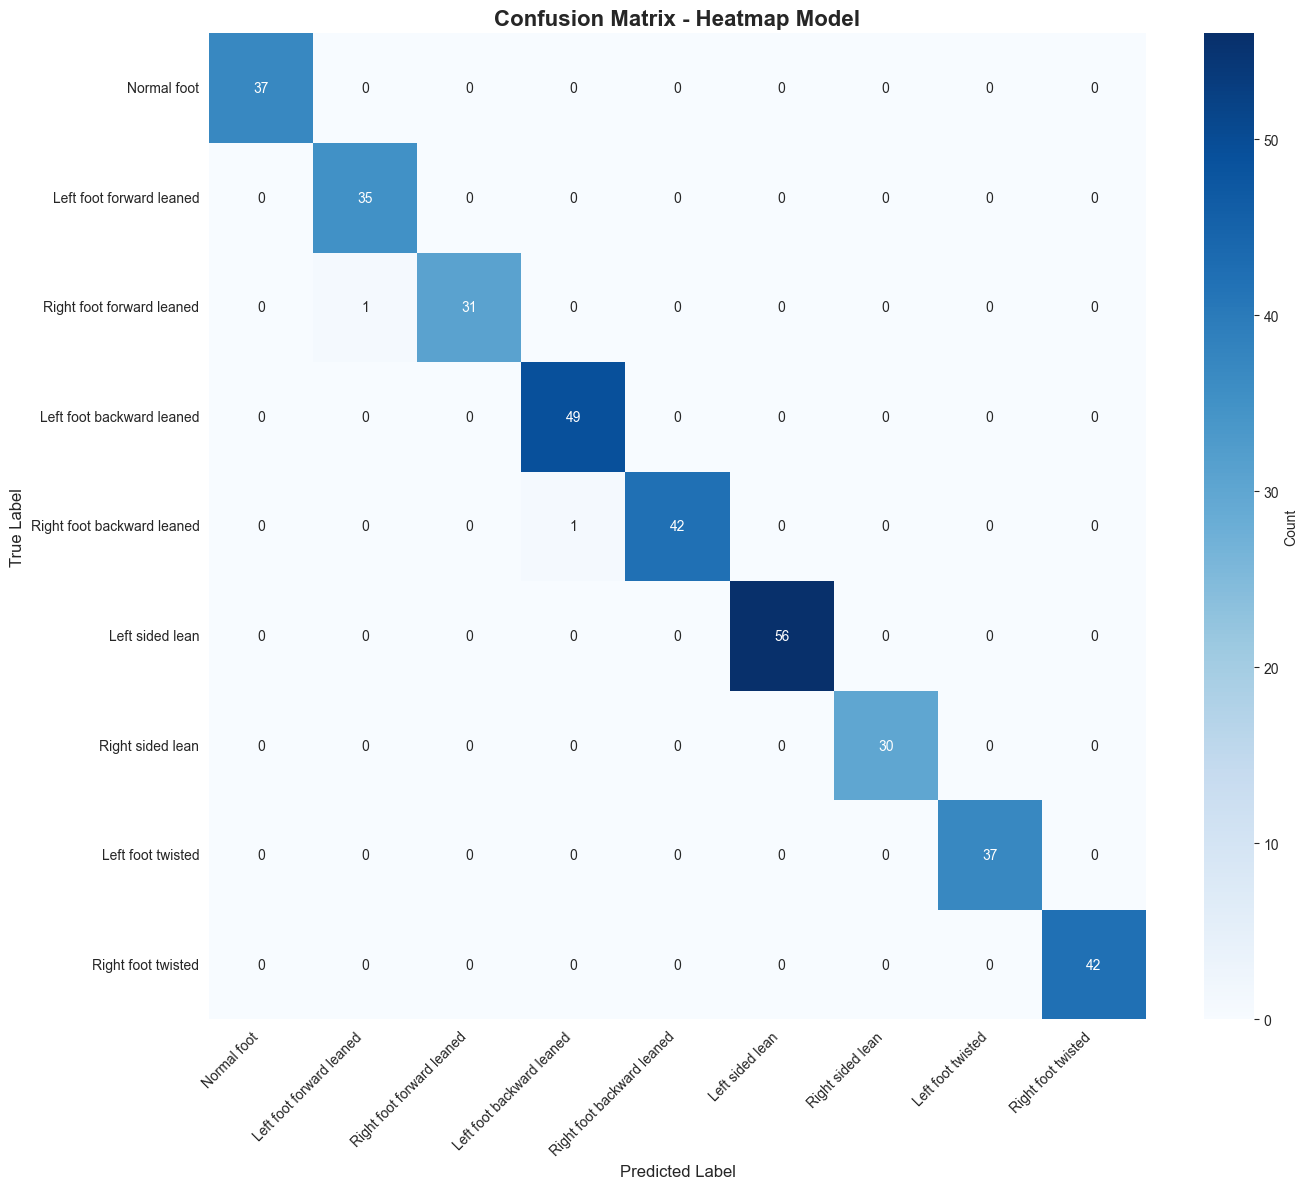

Confusion matrix saved as 'heatmap_confusion_matrix.png'


In [10]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Heatmap Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'heatmap_confusion_matrix.png'")


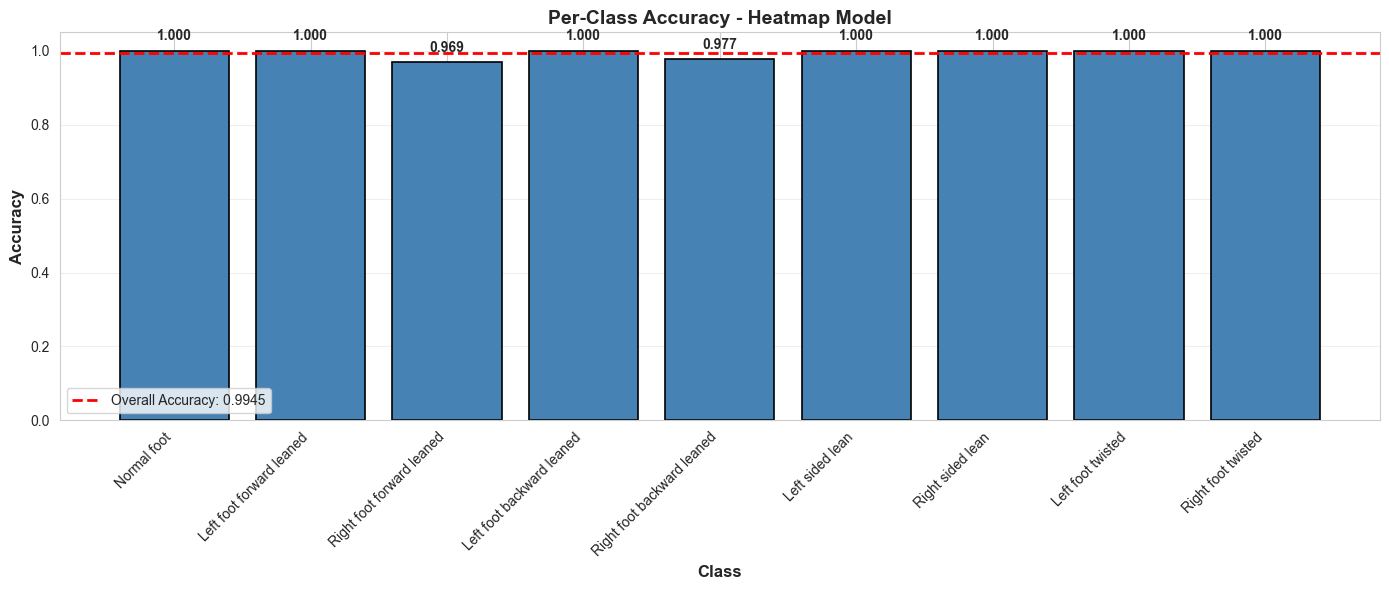

Per-class accuracy saved as 'heatmap_per_class_accuracy.png'


In [11]:
# Per-class accuracy metrics
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(class_names)), per_class_accuracy, color='steelblue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy - Heatmap Model', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylim([0, 1.05])
ax.axhline(y=accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall Accuracy: {accuracy:.4f}')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, per_class_accuracy)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('heatmap_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Per-class accuracy saved as 'heatmap_per_class_accuracy.png'")


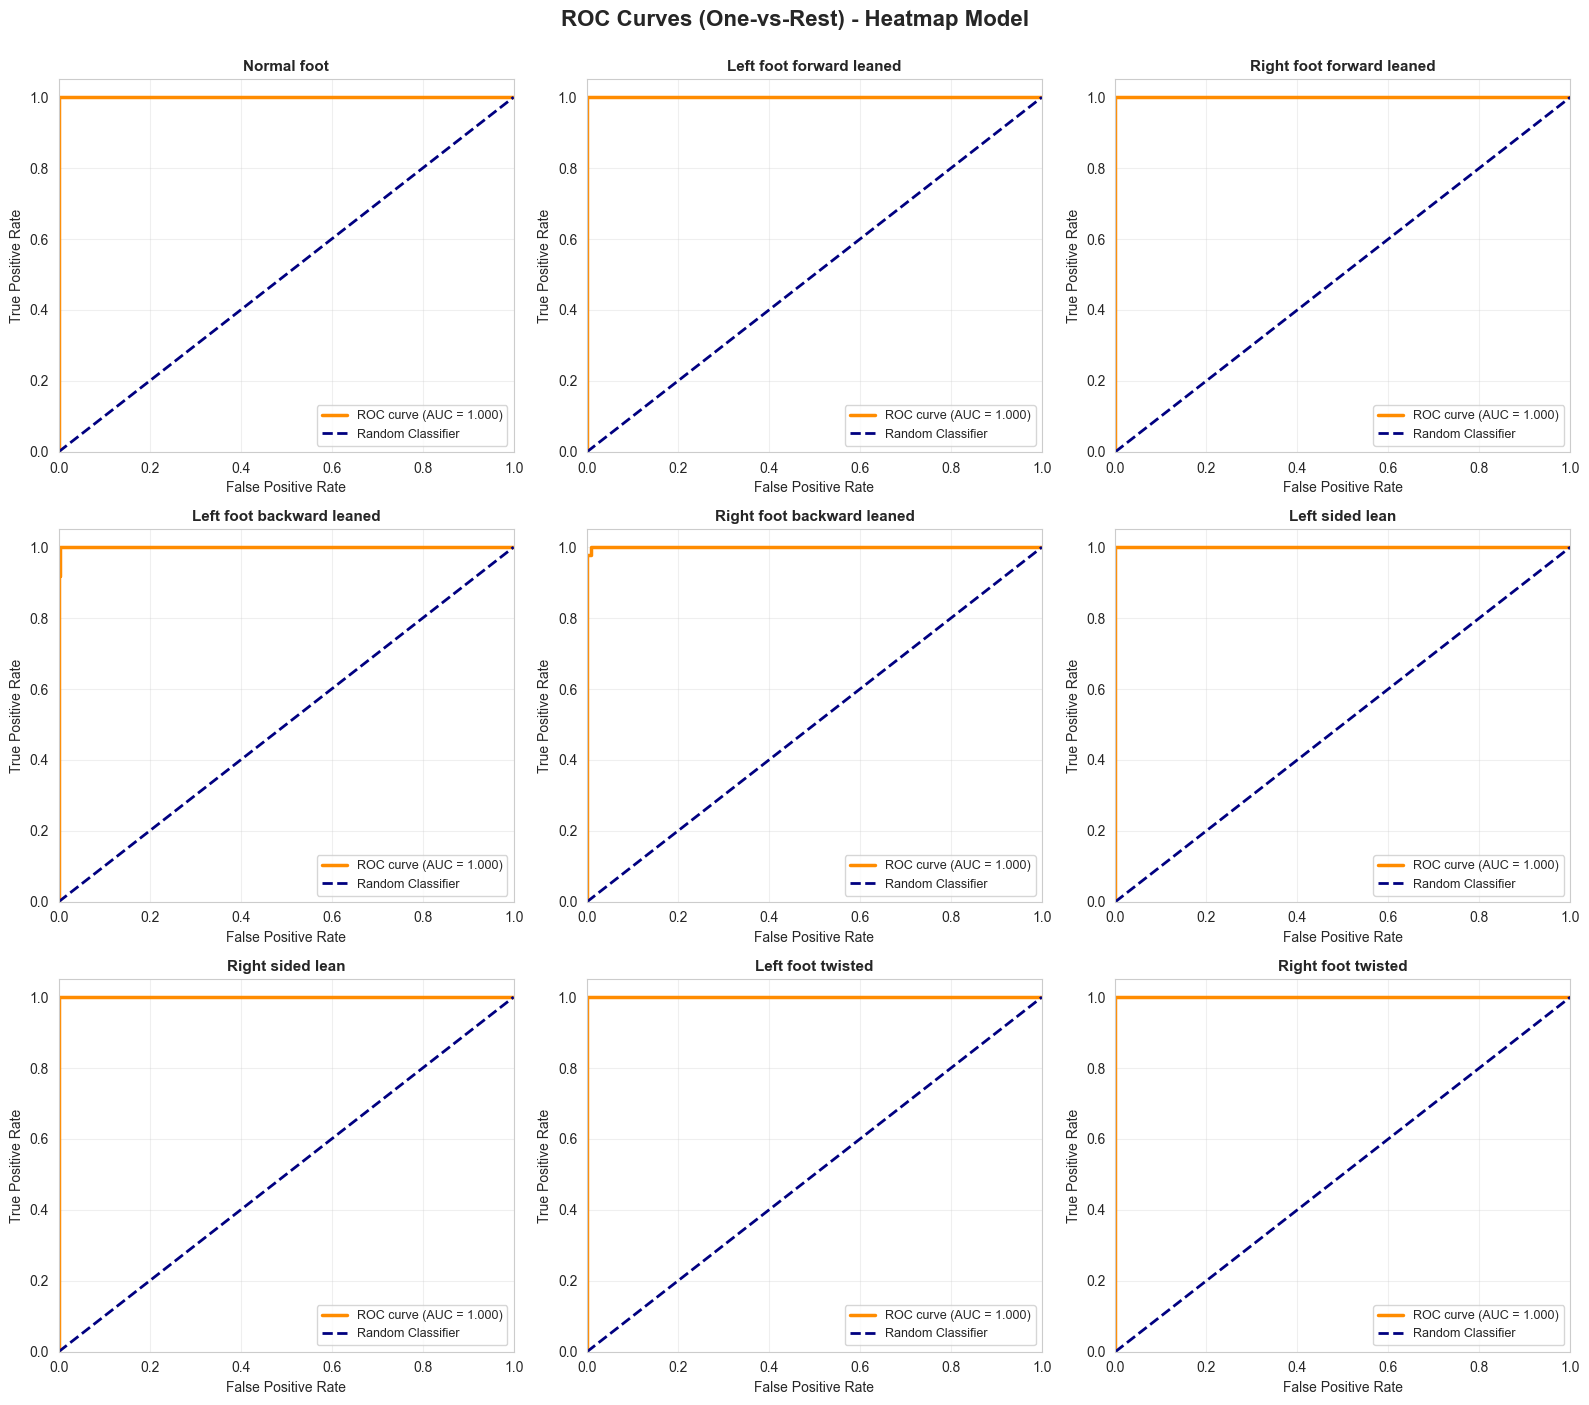

ROC curves saved as 'heatmap_roc_curves.png'


In [12]:
# ROC Curves (One-vs-Rest for each class)
n_classes = len(class_names)
y_bin = label_binarize(all_labels, classes=range(n_classes))

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=10)
    axes[i].set_ylabel('True Positive Rate', fontsize=10)
    axes[i].set_title(f'{class_names[i]}', fontsize=11, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('ROC Curves (One-vs-Rest) - Heatmap Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heatmap_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curves saved as 'heatmap_roc_curves.png'")


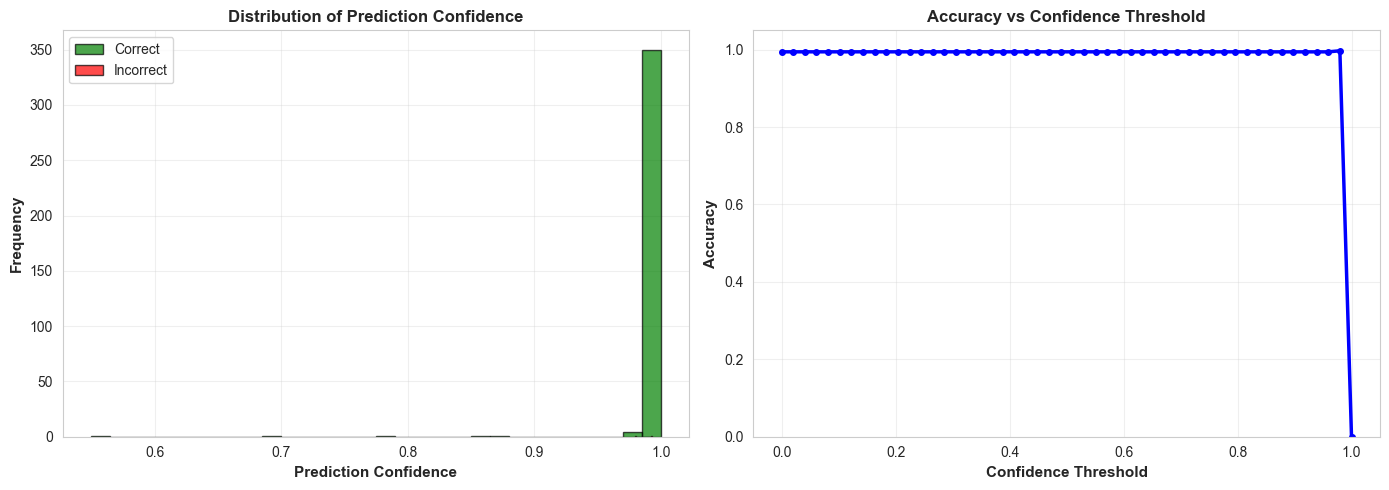

Confidence analysis saved as 'heatmap_confidence_analysis.png'


In [13]:
# Prediction confidence analysis
max_probs = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy vs confidence threshold
thresholds = np.linspace(0, 1, 50)
accuracies = []
counts = []

for threshold in thresholds:
    mask = max_probs >= threshold
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_labels[mask]).mean()
        accuracies.append(acc)
        counts.append(mask.sum())
    else:
        accuracies.append(0)
        counts.append(0)

axes[1].plot(thresholds, accuracies, 'b-', linewidth=2.5, marker='o', markersize=4)
axes[1].set_xlabel('Confidence Threshold', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Accuracy vs Confidence Threshold', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('heatmap_confidence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confidence analysis saved as 'heatmap_confidence_analysis.png'")


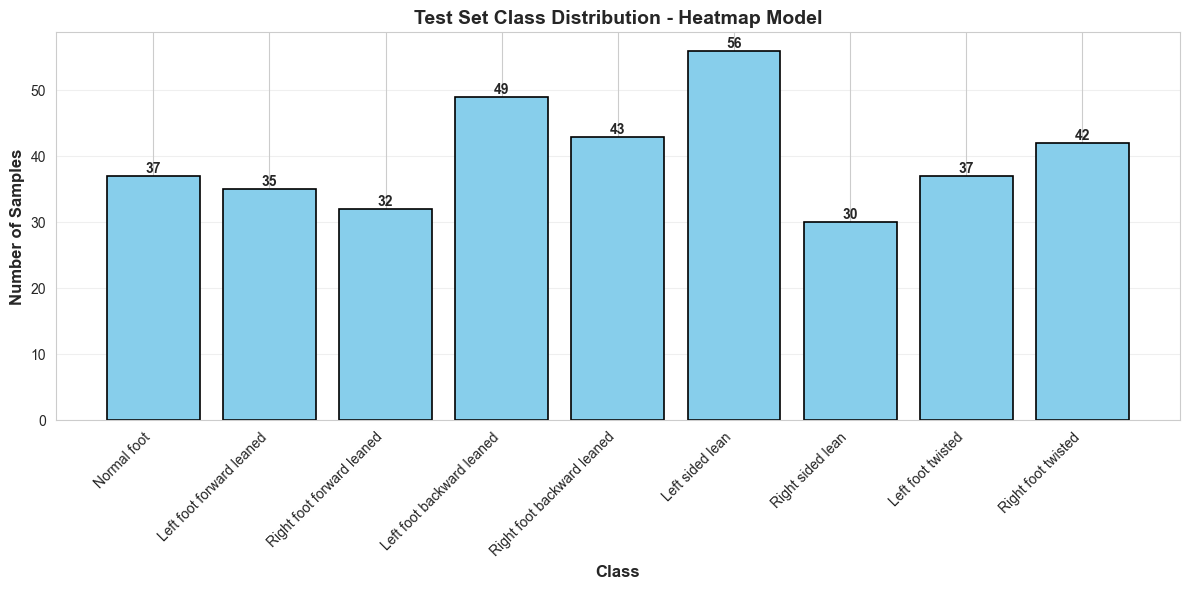

Class distribution saved as 'heatmap_class_distribution.png'


In [14]:
# Class distribution in test set
class_counts = np.bincount(all_labels, minlength=n_classes)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(n_classes), class_counts, color='skyblue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Test Set Class Distribution - Heatmap Model', fontsize=14, fontweight='bold')
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('heatmap_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Class distribution saved as 'heatmap_class_distribution.png'")


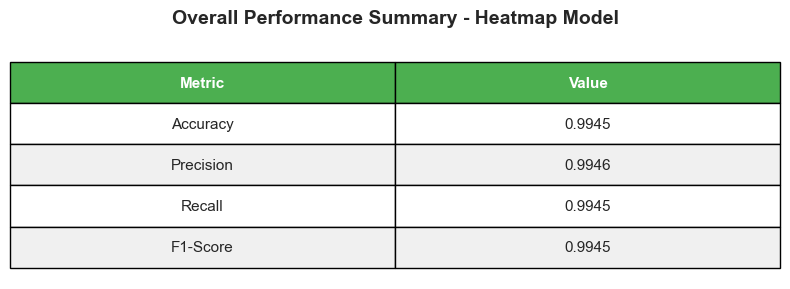

Summary metrics saved as 'heatmap_summary_metrics.png'


In [15]:
# Summary metrics table
summary_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}']
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=[[m, v] for m, v in zip(summary_data['Metric'], summary_data['Value'])],
                colLabels=['Metric', 'Value'],
                cellLoc='center',
                loc='center',
                colWidths=[0.5, 0.5])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Color header
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data['Metric']) + 1):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.title('Overall Performance Summary - Heatmap Model', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heatmap_summary_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary metrics saved as 'heatmap_summary_metrics.png'")